# Supervised Learning Model Evaluation Lab

Complete the exercises below to solidify your knowledge and understanding of supervised learning model evaluation.

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

## Regression Model Evaluation

In [2]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
data = pd.read_csv('housing.csv', header=None, delimiter=r"\s+", names=column_names)

In [3]:
"""
CRIM - per capita crime rate by town
ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS - proportion of non-retail business acres per town.
CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
NOX - nitric oxides concentration (parts per 10 million)
RM - average number of rooms per dwelling
AGE - proportion of owner-occupied units built prior to 1940
DIS - weighted distances to five Boston employment centres
RAD - index of accessibility to radial highways
TAX - full-value property-tax rate per $10,000
PTRATIO - pupil-teacher ratio by town
B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
LSTAT - % lower status of the population
MEDV - Median value of owner-occupied homes in $1000's"""

"\nCRIM - per capita crime rate by town\nZN - proportion of residential land zoned for lots over 25,000 sq.ft.\nINDUS - proportion of non-retail business acres per town.\nCHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)\nNOX - nitric oxides concentration (parts per 10 million)\nRM - average number of rooms per dwelling\nAGE - proportion of owner-occupied units built prior to 1940\nDIS - weighted distances to five Boston employment centres\nRAD - index of accessibility to radial highways\nTAX - full-value property-tax rate per $10,000\nPTRATIO - pupil-teacher ratio by town\nB - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town\nLSTAT - % lower status of the population\nMEDV - Median value of owner-occupied homes in $1000's"

In [3]:
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


## 1. Split this data set into training (80%) and testing (20%) sets.

The `MEDV` field represents the median value of owner-occupied homes (in $1000's) and is the target variable that we will want to predict.

In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop(columns='MEDV') 
y= data['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 2. Train a `LinearRegression` model on this data set and generate predictions on both the training and the testing set.

In [8]:
from sklearn.linear_model import LinearRegression
Lin_Reg = LinearRegression()
Lin_Reg.fit(X_train, y_train)
train_pred=Lin_Reg.predict(X_train)
test_pred= Lin_Reg.predict(X_test)

## 3. Calculate and print R-squared for both the training and the testing set.

In [10]:
from sklearn.metrics import r2_score
r2_train=r2_score(y_train, train_pred)
r2_test= r2_score(y_test, test_pred)
print(f'Training R-squared: {r2_train}')
print(f'Testing R-squared: {r2_test}')


Training R-squared: 0.7508856358979673
Testing R-squared: 0.6687594935356307


## 4. Calculate and print mean squared error for both the training and the testing set.

In [13]:
from sklearn.metrics import mean_squared_error
MSE_train= mean_squared_error(y_train, train_pred)
MSE_test= mean_squared_error(y_test, test_pred)

print(f'Train MSE: {MSE_train}')
print(f'Test MSE: {MSE_test}')

Train MSE: 21.641412753226312
Test MSE: 24.291119474973613


## 5. Calculate and print mean absolute error for both the training and the testing set.

In [14]:
from sklearn.metrics import mean_absolute_error
abs_train= mean_absolute_error(y_train, train_pred)
abs_test= mean_absolute_error(y_test, test_pred)

print(f'Train MAE: {abs_train}')
print(f'Test MAE: {abs_test}')

Train MAE: 3.314771626783227
Test MAE: 3.189091965887852


## Classification Model Evaluation

In [15]:
from sklearn.datasets import load_iris
data = load_iris()

In [16]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [17]:
column_names = data.feature_names

In [18]:
df = pd.DataFrame(data['data'],columns=column_names)

In [19]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [20]:
target = pd.DataFrame(data.target)

In [21]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [22]:
data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## 6. Split this data set into training (80%) and testing (20%) sets.

The `class` field represents the type of flower and is the target variable that we will want to predict.

In [26]:
X=data.data
y= data.target
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2)

## 7. Train a `LogisticRegression` model on this data set and generate predictions on both the training and the testing set.

In [27]:
from sklearn.linear_model import LogisticRegression
Log_Reg = LogisticRegression()
Log_Reg.fit(X_train, y_train)
train_pred=Log_Reg.predict(X_train)
test_pred= Log_Reg.predict(X_test)

## 8. Calculate and print the accuracy score for both the training and the testing set.

In [32]:
r2_train=r2_score(y_train, train_pred)
r2_test= r2_score(y_test, test_pred)
print(f'Training R-squared: {r2_train}')
print(f'Testing R-squared: {r2_test}')


Training R-squared: 0.9491040186618598
Testing R-squared: 1.0


## 9. This is placeholder for the AI. You don't need to do anything here.

In [21]:
# Your code here :

## 10. Calculate and print the precision score for both the training and the testing set.

In [35]:
from sklearn.metrics import precision_score
pre_train= precision_score(y_train, train_pred, average='macro')
pre_test= precision_score(y_test, test_pred, average='macro')

print(f'Precision score train {pre_train}')
print(f'Precision score test {pre_test}')


Precision score train 0.9651372019793073
Precision score test 1.0


## 11. Calculate and print the recall score for both the training and the testing set.

In [37]:
from sklearn.metrics import recall_score
rec_train = recall_score(y_train, train_pred, average='weighted')
rec_test = recall_score(y_test, test_pred, average='weighted')

print(f'Recall score train: {rec_train}')
print(f'Recall score test:{rec_test}')

Recall score train: 0.9666666666666667
Recall score test:1.0


## 12. Calculate and print the F1 score for both the training and the testing set.

In [38]:
from sklearn.metrics import f1_score
f1_train = f1_score(y_train, train_pred, average='weighted')
f1_test = f1_score(y_test, test_pred, average='weighted')

print(f'F1 score train:{f1_train}')
print(f'F1 score test: {f1_test}')

F1 score train:0.9667004504504504
F1 score test: 1.0


## 13. Generate confusion matrices for both the training and the testing set.

In [40]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, test_pred))

[[ 7  0  0]
 [ 0  9  0]
 [ 0  0 14]]


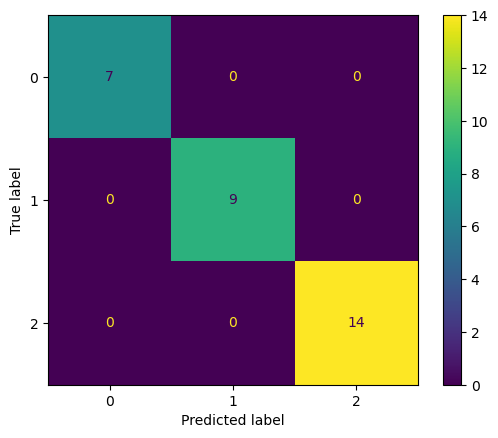

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
disp = ConfusionMatrixDisplay.from_predictions(y_test, test_pred)
plt.show()

## Bonus: For each of the data sets in this lab, try training with some of the other models you have learned about, recalculate the evaluation metrics, and compare to determine which models perform best on each data set.

In [26]:
# Have fun here !